# Análise de Dados — Desafio Prevision
Análise exploratória conectada ao banco SQLite, cobrindo MRR, churn e feedbacks.

In [1]:
import sqlite3
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

DB_PATH = os.path.join(os.path.expanduser('~'), 'desafio_prevision', 'airflow', 'data', 'prevision.db')
conn = sqlite3.connect(DB_PATH)
print('Conexão OK:', DB_PATH)

Conexão OK: /home/felipe/desafio_prevision/airflow/data/prevision.db


---
## 1. Visão Geral dos Clientes

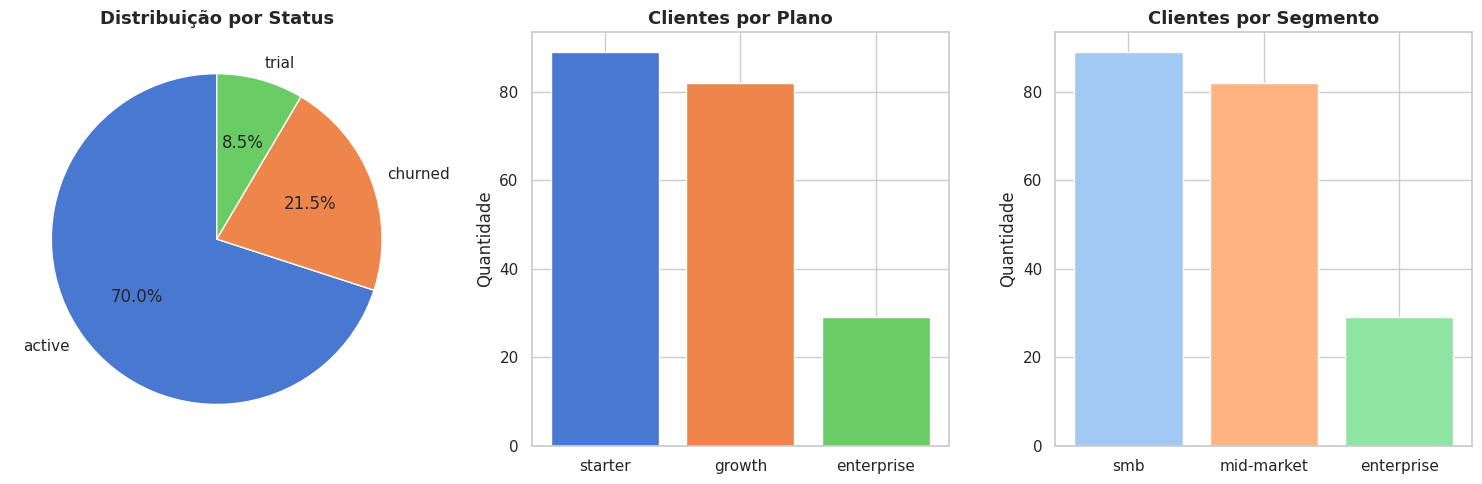

In [2]:
df_customers = pd.read_sql('SELECT * FROM silver_customers', conn)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Status
status_counts = df_customers['status'].value_counts()
axes[0].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Distribuição por Status')

# Plano
plan_counts = df_customers['plan'].value_counts()
axes[1].bar(plan_counts.index, plan_counts.values, color=sns.color_palette('muted', len(plan_counts)))
axes[1].set_title('Clientes por Plano')
axes[1].set_ylabel('Quantidade')

# Segmento
seg_counts = df_customers['segment'].value_counts()
axes[2].bar(seg_counts.index, seg_counts.values, color=sns.color_palette('pastel', len(seg_counts)))
axes[2].set_title('Clientes por Segmento')
axes[2].set_ylabel('Quantidade')

plt.tight_layout()
plt.show()

---
## 2. MRR por Dimensão

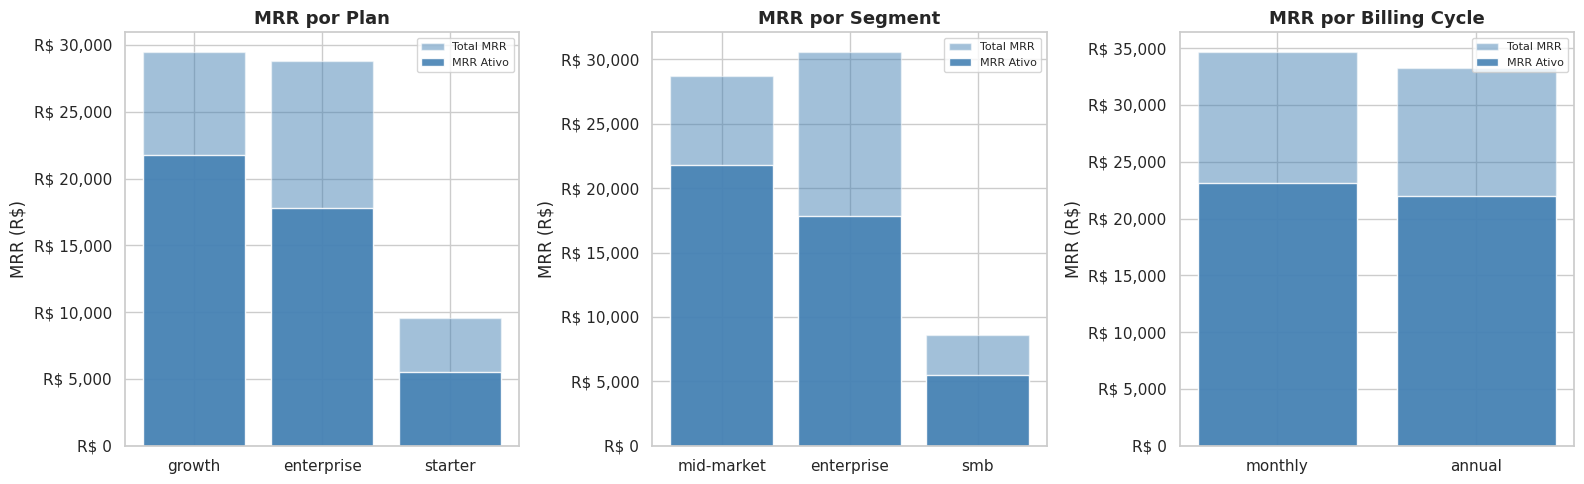

In [3]:
df_mrr = pd.read_sql('SELECT * FROM gold_mrr_by_dimension', conn)

dims = ['plan', 'segment', 'billing_cycle']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, dim in zip(axes, dims):
    data = df_mrr[df_mrr['dimension'] == dim].sort_values('active_mrr', ascending=False)
    x = data['dimension_value']
    ax.bar(x, data['total_mrr'], label='Total MRR', alpha=0.5, color='steelblue')
    ax.bar(x, data['active_mrr'], label='MRR Ativo', alpha=0.9, color='steelblue')
    ax.set_title(f'MRR por {dim.replace("_", " ").title()}')
    ax.set_ylabel('MRR (R$)')
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 3. Análise de Churn

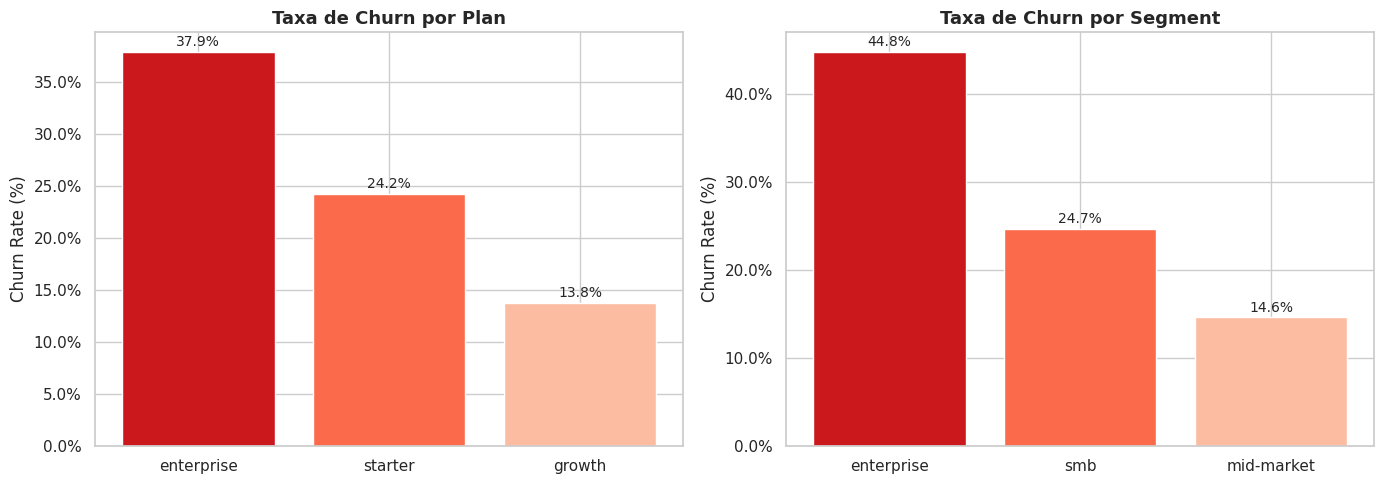

In [4]:
df_churn = pd.read_sql('SELECT * FROM gold_churn_analysis', conn)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, dim in zip(axes, ['plan', 'segment']):
    data = df_churn[df_churn['dimension'] == dim].sort_values('churn_rate_pct', ascending=False)
    bars = ax.bar(data['dimension_value'], data['churn_rate_pct'],
                  color=sns.color_palette('Reds_r', len(data)))
    ax.set_title(f'Taxa de Churn por {dim.title()}')
    ax.set_ylabel('Churn Rate (%)')
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.1f}%'))
    for bar, val in zip(bars, data['churn_rate_pct']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

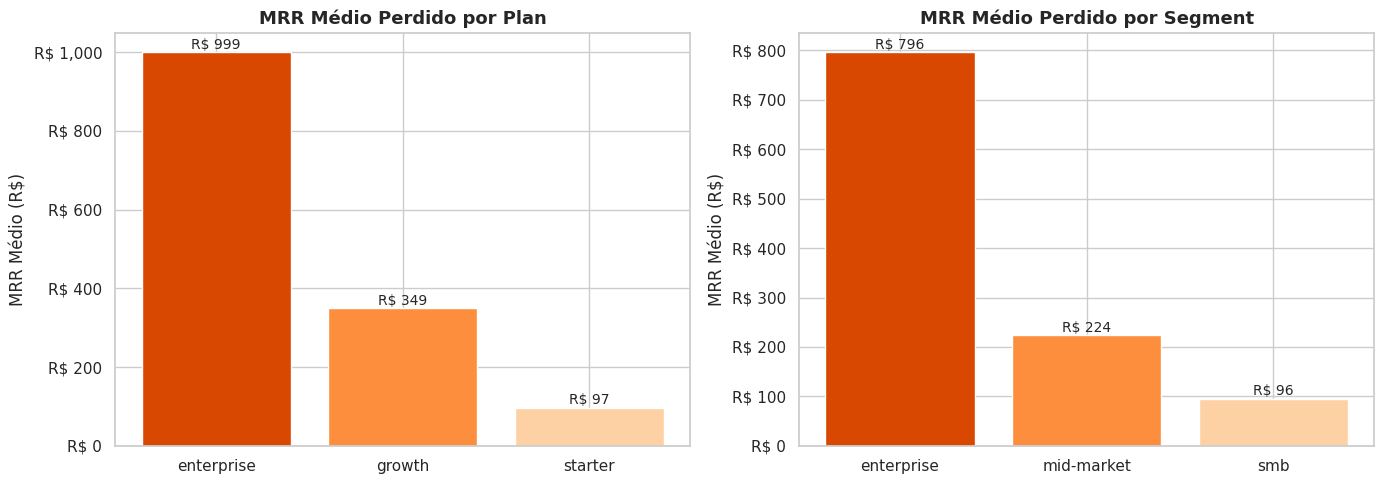

In [5]:
# MRR perdido por churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, dim in zip(axes, ['plan', 'segment']):
    data = df_churn[df_churn['dimension'] == dim].sort_values('avg_mrr_lost', ascending=False)
    bars = ax.bar(data['dimension_value'], data['avg_mrr_lost'],
                  color=sns.color_palette('Oranges_r', len(data)))
    ax.set_title(f'MRR Médio Perdido por {dim.title()}')
    ax.set_ylabel('MRR Médio (R$)')
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
    for bar, val in zip(bars, data['avg_mrr_lost']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'R$ {val:,.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

---
## 4. Relação entre Tipo de Feedback e Churn
Pergunta obrigatória do desafio: *existe relação entre o tipo de feedback e o churn?*

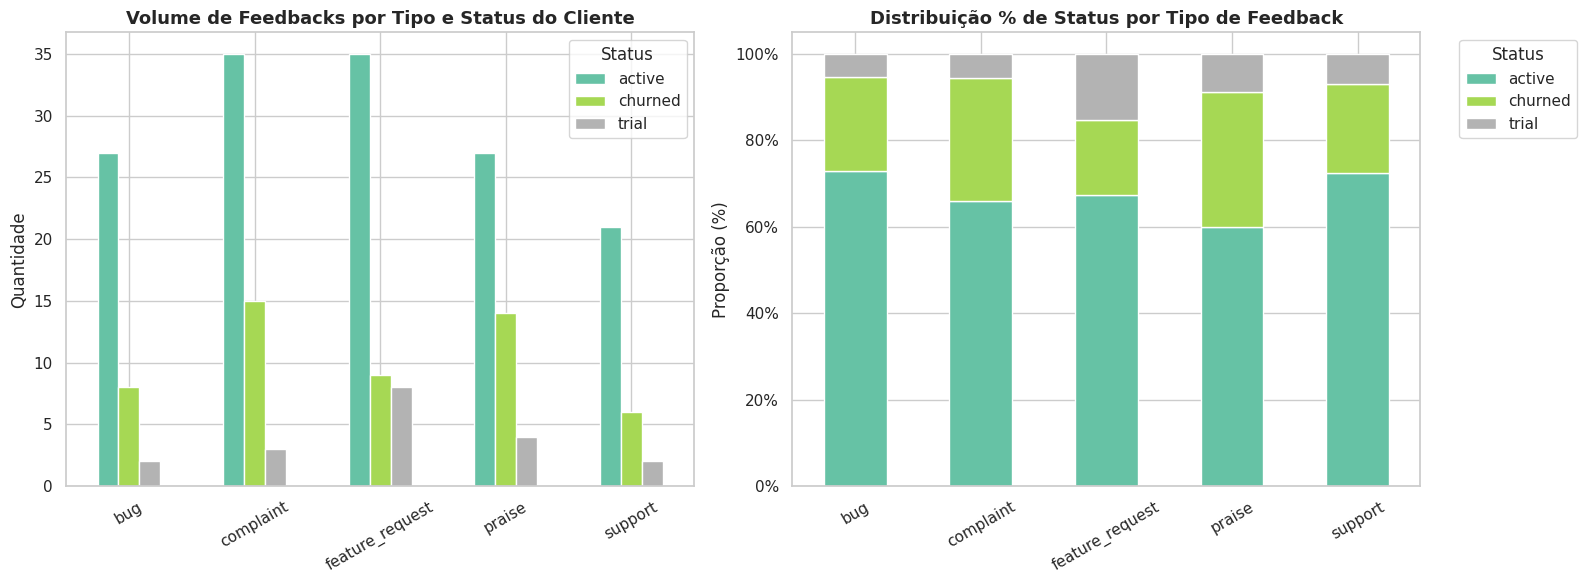

In [6]:
query = """
SELECT
    f.type,
    c.status,
    COUNT(*) as total
FROM silver_feedbacks f
JOIN silver_customers c ON f.customer_id = c.customer_id
GROUP BY f.type, c.status
ORDER BY f.type, c.status
"""
df_fb_churn = pd.read_sql(query, conn)

pivot = df_fb_churn.pivot(index='type', columns='status', values='total').fillna(0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pivot.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white')
axes[0].set_title('Volume de Feedbacks por Tipo e Status do Cliente')
axes[0].set_ylabel('Quantidade')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Status')

pivot_pct.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2', edgecolor='white')
axes[1].set_title('Distribuição % de Status por Tipo de Feedback')
axes[1].set_ylabel('Proporção (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
axes[1].legend(title='Status', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

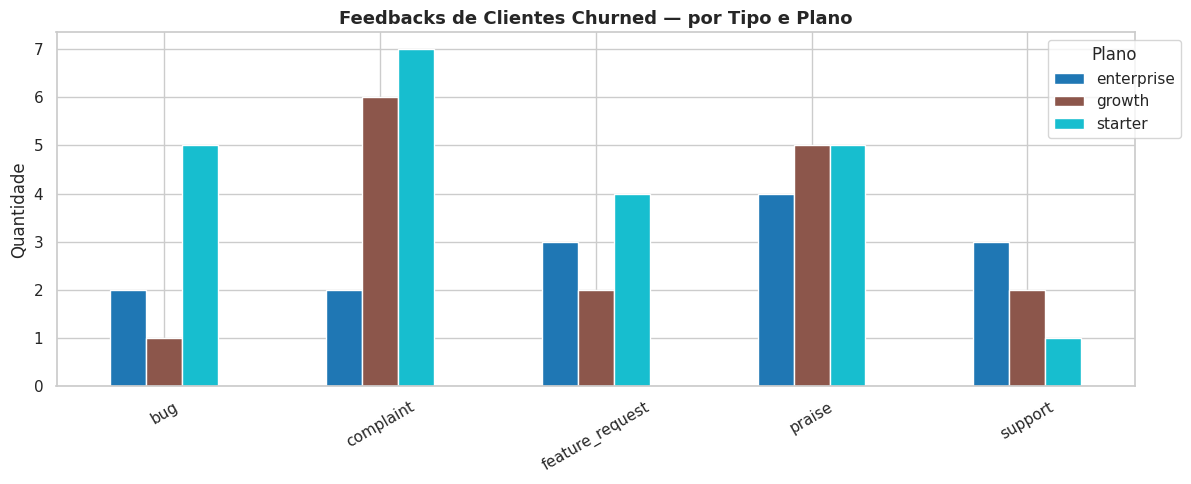

In [7]:
# Tipo de feedback x Churn por segmento de plano
query2 = """
SELECT
    f.type,
    c.plan,
    c.status,
    COUNT(*) as total
FROM silver_feedbacks f
JOIN silver_customers c ON f.customer_id = c.customer_id
WHERE c.status = 'churned'
GROUP BY f.type, c.plan
ORDER BY c.plan, total DESC
"""
df_churn_plan = pd.read_sql(query2, conn)

pivot2 = df_churn_plan.pivot(index='type', columns='plan', values='total').fillna(0)

pivot2.plot(kind='bar', figsize=(12, 5), colormap='tab10', edgecolor='white')
plt.title('Feedbacks de Clientes Churned — por Tipo e Plano')
plt.ylabel('Quantidade')
plt.xlabel('')
plt.xticks(rotation=30)
plt.legend(title='Plano', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

---
## 5. Métricas de Feedback

/tmp/ipykernel_53643/268504449.py:28: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


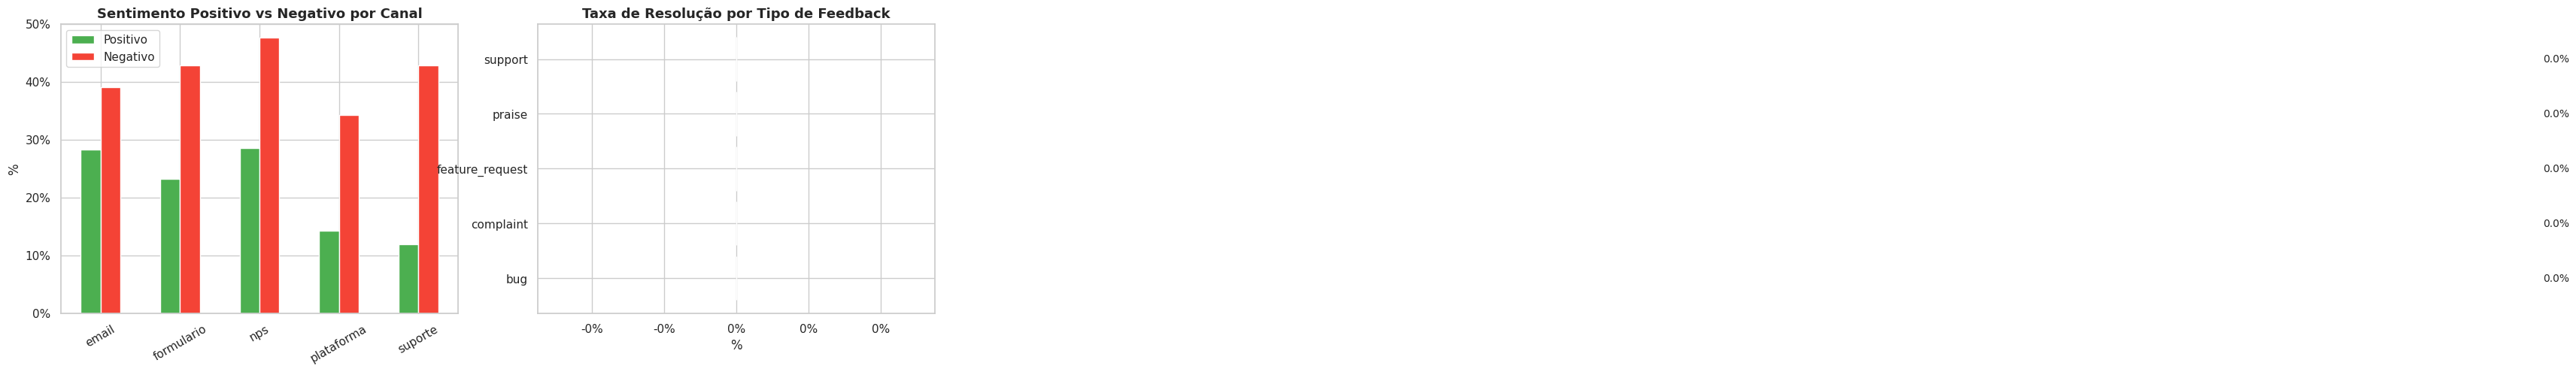

In [8]:
df_fb = pd.read_sql('SELECT * FROM gold_feedback_metrics', conn)

# Sentimento por canal
data_channel = df_fb[df_fb['dimension'] == 'channel'][['dimension_value', 'positive_pct', 'negative_pct']]
data_channel = data_channel.set_index('dimension_value')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

data_channel.plot(kind='bar', ax=axes[0], color=['#4CAF50', '#F44336'], edgecolor='white')
axes[0].set_title('Sentimento Positivo vs Negativo por Canal')
axes[0].set_ylabel('%')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
axes[0].legend(['Positivo', 'Negativo'])

# Taxa de resolução por tipo
data_type = df_fb[df_fb['dimension'] == 'type'][['dimension_value', 'resolution_rate_pct']]
data_type = data_type.sort_values('resolution_rate_pct', ascending=True)
axes[1].barh(data_type['dimension_value'], data_type['resolution_rate_pct'],
             color=sns.color_palette('Blues_r', len(data_type)))
axes[1].set_title('Taxa de Resolução por Tipo de Feedback')
axes[1].set_xlabel('%')
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
for i, val in enumerate(data_type['resolution_rate_pct']):
    axes[1].text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

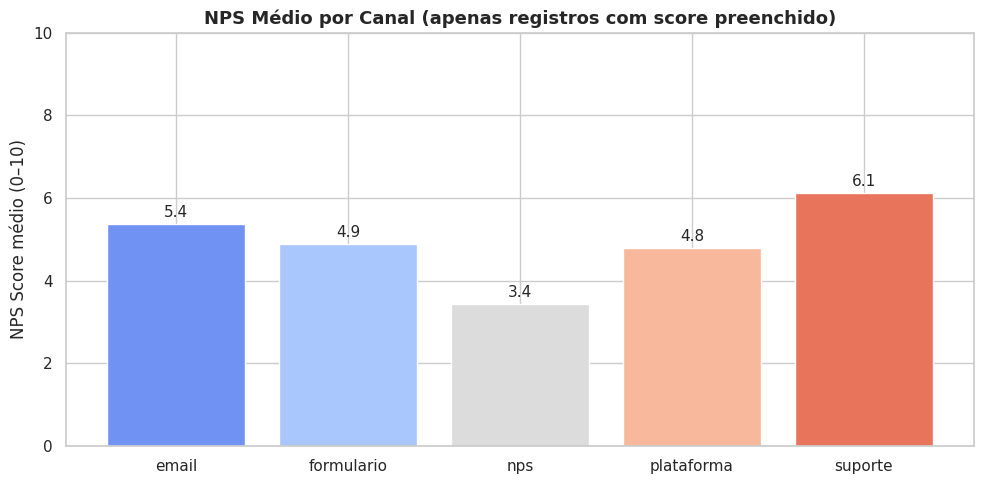

In [9]:
# NPS por canal (apenas onde há scores válidos)
data_nps = df_fb[df_fb['dimension'] == 'channel'].dropna(subset=['avg_nps_score'])

if not data_nps.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(data_nps['dimension_value'], data_nps['avg_nps_score'],
                  color=sns.color_palette('coolwarm', len(data_nps)))
    ax.set_title('NPS Médio por Canal (apenas registros com score preenchido)')
    ax.set_ylabel('NPS Score médio (0–10)')
    ax.set_ylim(0, 10)
    for bar, val in zip(bars, data_nps['avg_nps_score']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.1f}', ha='center', va='bottom', fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print('Sem dados de NPS suficientes para plotar.')

In [ ]:
conn.close()
print('Conexão encerrada .')

Conexão encerrada.
